# FENS-Chen summer school 2026 - learning with spikes (Dan Goodman)

Import a few things we'll need.

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from tqdm.notebook import tqdm

dtype = torch.float
device = torch.device('cpu')

The task here is a very simple time difference tasks. We generate Poisson distributed spikes for the first N/2 spike channels, and then we offset the second N/2 channels by some amount, and the task is to infer the offset amount. If you had delays you could do this very easily with a coincidence detector, but in this notebook we don't allow delays.

In [69]:
def offset_poisson_spike_trains(N, duration, rate, offset):
  assert N%2==0
  dt = 1
  n_bins = int(np.ceil(duration / dt))
  # first half is Poisson
  spikes_half = np.array(np.random.rand(N//2, n_bins)<rate*dt, dtype=float)
  # second half is a shifted (rolled) version of first half
  spikes = np.concatenate((spikes_half, np.roll(spikes_half, offset, axis=1)), axis=0)
  return spikes

# This little helper class will be used to store the task, params and generate
# data for training and testing
class OffsetTask:
  def __init__(self, num_neurons, available_offsets, rate, duration):
    self.num_neurons = num_neurons
    self.available_offsets = available_offsets
    self.duration = duration
    self.rate = rate
    self.dt = dt = 1
    self.num_timesteps = int(duration / dt)
    self.num_classes = len(self.available_offsets)

  def generate_batch(self, batch_size, use_torch=True):
    # Spikes should have shape (batch_size, num_timesteps, num_neurons)
    # offset_indices should have shape (batch_size,)
    offset_indices = np.random.randint(0, self.num_classes, size=batch_size)
    # generate spike trains
    all_spikes = []
    for offset_index in offset_indices:
      offset = self.available_offsets[offset_index]
      spikes = offset_poisson_spike_trains(self.num_neurons, self.duration, self.rate, offset)
      all_spikes.append(spikes)
    all_spikes = np.array(all_spikes, dtype=np.float32)
    if use_torch:
      offset_indices = torch.from_numpy(offset_indices).to(device)
      all_spikes = torch.from_numpy(all_spikes).to(device)
    return offset_indices, all_spikes

dataset = OffsetTask(num_neurons=10, available_offsets=np.arange(0,20,2), rate=50/1000, duration=1000)

# Quick visualisation of the output
offsets, spikes = dataset.generate_batch(1, use_torch=False)
print(spikes.shape)
print(offsets)
plt.imshow(spikes[0, :, :], origin='lower', aspect='auto', interpolation='nearest')

This is the surrogate Heaviside we use for surrogate gradient descent.

In [4]:
# This is the surrogate Heaviside we use for surrogate gradient descent
class SurrogateHeaviside(torch.autograd.Function):
    scale = 100.0 # controls steepness of surrogate gradient
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        out = torch.zeros_like(input)
        out[input > 0] = 1.0
        return out
    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        grad = grad_input/(SurrogateHeaviside.scale*torch.abs(input)+1.0)**2
        return grad
surrogate_heaviside  = SurrogateHeaviside.apply

The next bit of code implements a spiking neural network using the surrogate Heaviside.

In [46]:
# This class implements a single layer of LIF or just leaky non-spiking neurons
class SNNLayer(nn.Module):
  def __init__(self, n_in, n_out, spiking=True, return_membrane_potentials=False, **params):
    super(SNNLayer, self).__init__()
    self.n_in = n_in
    self.n_out = n_out
    # Parameters for the underlying neuron model
    # This dictionary gives the default values which can be overrided
    # by the user specified parameters
    self.params = dict(
        dt = 1,
        tau_trainable = True,
        tau_shared = False,
        )
    self.params.update(**params)
    # Store weights as a trainable parameter
    self.w = nn.Parameter(torch.ones((n_in, n_out)))
    # Time constants can be shared or not, trainable or not
    if self.params['tau_shared']:
      n_tau = 1
    else:
      n_tau = n_out
    if self.params['tau_trainable']:
      self.tau = nn.Parameter(torch.ones((n_tau,)))
    else:
      self.tau = torch.ones((n_tau,)) # will still get initialised later
    self.spiking = spiking
    self.return_membrane_potentials = return_membrane_potentials

  def forward(self, x):
    batch_size, num_neurons, num_time_points = x.shape
    assert num_neurons==self.n_in
    v = torch.zeros((batch_size, self.n_out)) # membrane potential
    s = torch.zeros((batch_size, self.n_out)) # spiking
    # we use this to simplify the equations for the LIF below
    alpha = torch.exp(-self.params['dt']/self.tau)
    # the next line computes the result of multiplying input spike trains with
    # the weight matrix and providing them at the right time
    h = torch.einsum('bit,ij->bjt', (x, self.w))
    # Do we want spiking or non-spiking output?
    if self.spiking:
      rec = [s]
      rec_v = [v]
    else:
      rec = [v]
    # Now we just iterate through all the times, updating membrane potentials
    # and checking for spikes as we go - remembering to use our surrogate
    # heaviside to check for spikes!
    for t in range(num_time_points-1):
      new_v = (v*alpha+h[:, :, t])
      v = new_v
      # handle two possible cases of spiking or no spiking
      if self.spiking:
        v = v*(1-s)
        s = surrogate_heaviside(v-1) # condition v>1
      if self.spiking:
        rec.append(s)
        if self.return_membrane_potentials:
          rec_v.append(v)
      else:
        rec.append(v)
    y = torch.stack(rec, dim=2)
    if self.spiking and self.return_membrane_potentials:
      return y, torch.stack(rec_v, dim=2)
    else:
      return y

# This is just a very simple (non-Pytorch) class that generates a chain of layers connected
# to each other. You should probably use torch.nn.Sequential instead but I was in a hurry.
class MultilayerSNN:
  def __init__(self, layer_sizes, params, fname='default.pt'):
    self.layer_sizes = layer_sizes
    self.params = params
    self.num_layers = len(layer_sizes)-1
    self.networks = []
    self.parameters = []
    self.fname = fname
    for n_in, n_out, p in zip(layer_sizes[:-1], layer_sizes[1:], params):
      net = SNNLayer(n_in, n_out, **p)
      # net = torch.compile(net) # this doesn't work on windows but might speed up on linux
      # Uniform initialisation works well
      nn.init.uniform_(net.w, *p['w_init'])
      nn.init.uniform_(net.tau, *p['tau_init'])
      # You could also try normal or truncated normal initialisation
      # nn.init.normal_(net.w, *p['w_init'])
      # nn.init.trunc_normal_(net.w, *p['w_init'])
      self.networks.append(net)
      self.parameters.append(net.w)
      self.parameters.append(net.tau)

  # this function just takes the output of one layer and feeds to the next
  def __call__(self, x, record=False):
    rec = []
    for net in self.networks:
      if net.n_out==2:
        x = net(x)
      else:
        x = net(x)
      if record:
        rec.append(x)
    if record:
      return x, rec
    else:
      return x

  def save(self):
    torch.save(self, self.fname)


The next function just computes performance on a random sample of 100 values.

In [10]:
def evaluate(net, dataset, test_size=100):
  refractory, spikes = dataset.generate_batch(test_size)
  with torch.no_grad():
    v_out = net(spikes)
    m = torch.mean(v_out, 2)
    refractory_est = torch.argmax(m, dim=1)
    acc = torch.mean((refractory_est==refractory).float())
    return acc

Specifications for the model in terms of layer sizes and parameters.

In [75]:
model_specs = dict(
    homogeneous = dict(
        hidden_dimensions=(20,),
        params=[
          dict(w_init=(-2, 2), tau_init=(1, 20), tau_shared=True, tau_trainable=True),
          # dict(w_init=(-2, 2), tau_init=(1, 20), tau_shared=True, tau_trainable=True),
          dict(spiking=False, w_init=(-0.02, 0.02), tau_shared=True, tau_trainable=False, tau_init=(50, 50)),
          ],
        ),
    # Heterogeneous commented out because it actually does worse at this task
    # heterogeneous = dict(
    #     hidden_dimensions=(20,),
    #     params=[
    #       dict(w_init=(-2, 2), tau_init=(1, 20), tau_shared=False, tau_trainable=True),
    #       # dict(w_init=(-2, 2), tau_init=(1, 20), tau_shared=False, tau_trainable=True),
    #       dict(spiking=False, w_init=(-0.02, 0.02), tau_shared=True, tau_trainable=False, tau_init=(50, 50)),
    #       ],
    #     ),
)
networks = {name: MultilayerSNN((dataset.num_neurons,)+spec['hidden_dimensions']+(dataset.num_classes,), spec['params'], fname=name) for name, spec in model_specs.items()}

We quickly check that with this initialisation we get every layer firing some spikes and some reasonable traces at the output.

83.35000276565552 sp/s


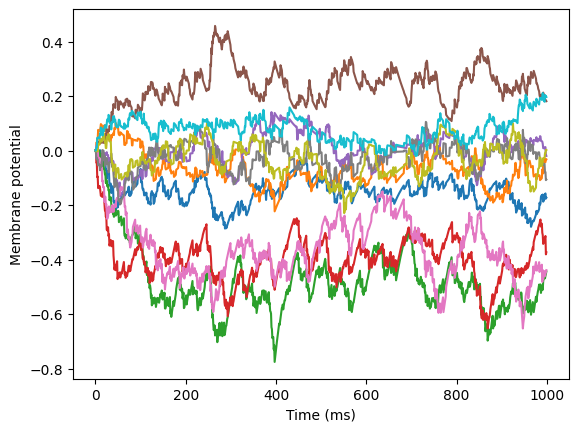

In [78]:
# Debugging output is in a reasonable range
ref, spikes = dataset.generate_batch(1)
with torch.no_grad():
  net = networks['homogeneous']
  x, rec = net(spikes, record=True)
  for spk in rec[:-1]:
    print(float(spk.mean())*1000, 'sp/s') # firing rate for spiking layers
  plt.plot(x[0,:,:].T); # output traces should show some variation
  plt.xlabel('Time (ms)')
  plt.ylabel('Membrane potential')

And now for training. Pretty much everything here is quite standard for training a classifier with PyTorch. The output of the network is an array of output neuron membrane potential traces. We just take the mean value of these, and use this precisely as we would the output of an artificial neural network. Because we're doing classification, i.e. cross-entropy loss function. If you don't know what this is, basically imagine that we want the output to look like a probability distribution for each of the possible classes. Ideally, it should be probability of 1 for the correct class, and 0 for all others. The loss function just says how far away from this ideal we are in a nice way that has been shown to be good for learning with gradient descent.

  0%|          | 0/100 [00:00<?, ?it/s]

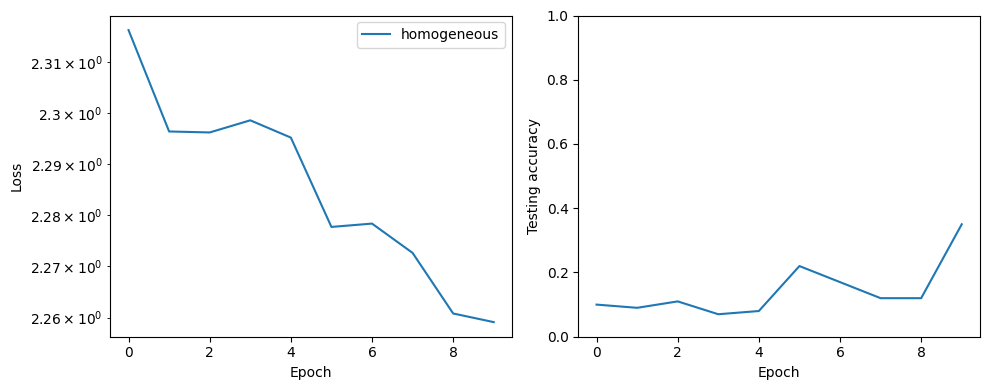

In [ ]:
# Training parameters
lr = 0.01 # learning rate
num_epochs = 10
num_batches = 10
batch_size = 32

log_softmax_fn = nn.LogSoftmax(dim=1)
loss_fn = nn.NLLLoss()

def train_network(net, debug_output=False, loss_fig=None):
  # Optimiser and loss function
  optimizer = torch.optim.Adam(net.parameters, lr=lr)
  # Training
  loss_hist = []
  acc_hist = []
  with tqdm(total=num_epochs*num_batches) as pbar: # progress bar
    last_epoch_loss = None
    last_epoch_acc = None
    for epoch in range(num_epochs):
      local_loss = []
      for batch_num in range(num_batches):
        y, x = dataset.generate_batch(batch_size=batch_size)
        # Run the network
        v_out, rec = net(x, record=True)
        # Compute a loss
        m = torch.mean(v_out, 2)
        loss = loss_fn(log_softmax_fn(m), y)
        if batch_num==0 and debug_output:
          with torch.no_grad():
            print(f'{epoch=}')
            for spk in rec[:-1]:
              print(spk.mean()*1000) # firing rate for spiking layers
            plt.figure()
            plt.plot(v_out[0,:,:].T); # output traces should show some variation
            print(v_out.shape, m.shape, y.shape, loss.item())
            print(m[0,:], log_softmax_fn(m)[0,:], y[0])
        local_loss.append(loss.item())
        # Update gradients
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
          for subnet in net.networks:
            # ensure that taus remain positive
            subnet.tau.clamp_(min=1)
        pbar.update(1)
        pbar.set_postfix(epoch=epoch, last_epoch_loss=last_epoch_loss, loss=loss.item(), last_epoch_acc=last_epoch_acc)
      last_epoch_loss = np.mean(local_loss)
      acc = evaluate(net, dataset)
      last_epoch_acc = acc
      pbar.set_postfix(epoch=epoch, last_epoch_loss=last_epoch_loss, loss=loss.item(), last_epoch_acc=last_epoch_acc)
      loss_hist.append(last_epoch_loss)
      acc_hist.append(acc)

  net.trained = True

  return loss_hist, acc_hist

# Train all the networks and plot their loss and accuracy curves over training
plt.figure(figsize=(10, 4))
for net in networks.values():
  loss_hist, acc_hist = train_network(net)
  plt.subplot(121)
  plt.semilogy(loss_hist, label=net.fname)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(loc='best')
  plt.subplot(122)
  plt.plot(acc_hist)
  plt.ylim(0, 1)
  plt.xlabel('Epoch')
  plt.ylabel('Testing accuracy')
  plt.tight_layout();

This bit of code visualises the time constants learned by the networks as a histogram.

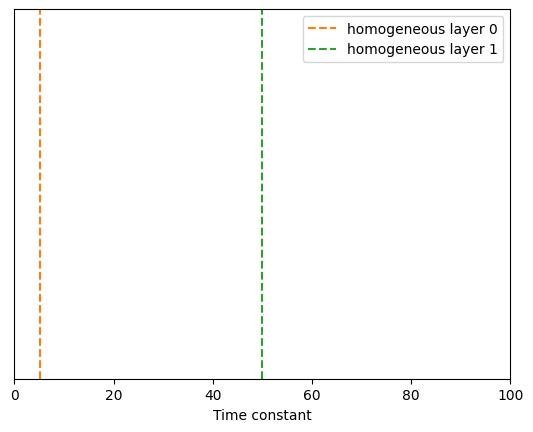

In [80]:
with torch.no_grad():
  j = 0
  for net in networks.values():
    for i, n in enumerate(net.networks):
      j += 1
      tau = n.tau.numpy()
      if len(tau)>1:
        plt.hist(tau, label=f'{net.fname} layer {i}', alpha=0.5, fc=f'C{j}')
      else:
        plt.axvline(tau, label=f'{net.fname} layer {i}', ls='--', c=f'C{j}')
    plt.xlabel('Time constant')
    plt.xlim(0, 100)
    plt.legend(loc='best')
    plt.yticks([])